<a href="https://colab.research.google.com/github/N17-R4M/bigdata-lab-FFLM/blob/main/Analise_Explorat%C3%B3ria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Big Data: Análise do Exame Nacional (2024)

Este notebook apresenta a etapa de Análise Exploratória de Dados (EDA) e Limpeza das bases do exame.
Para garantir a colaboração e evitar limitações de memória, os dados estão hospedados no Google Drive, permitindo que toda a nova equipe acesse a mesma fonte de dados de forma sincronizada.

### 🚩 Nota para a Equipe (Setup do Ambiente)

Para que este notebook funcione perfeitamente na máquina de qualquer membro do grupo, sigam estes passos:
1. Abram o e-mail neutro do projeto e acessem o Google Drive compartilhado.
2. Garantam que os arquivos `PARTICIPANTES_2024.csv`, `RESULTADOS_2024.csv` e `ITENS_PROVA_2024.csv` estão salvos dentro de uma pasta chamada `Projeto_ENEM` no Drive.
3. Ao executar a primeira célula deste código, o Colab pedirá permissão para acessar o Drive. Basta autorizar e rodar o resto do notebook!

In [1]:
# Ingestão e Processamento

import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")

drive.mount('/content/drive')
caminho_drive = '/content/drive/MyDrive/Projeto_ENEM/'

# Lendo com o separador correto e ignorando a base de Itens
# O parâmetro low_memory=False ajuda com bases grandes onde o Pandas se perde nos tipos de dados
df_participantes = pd.read_csv(caminho_drive + 'PARTICIPANTES_2024.csv', sep=';', encoding='latin1', low_memory=False)
df_resultados = pd.read_csv(caminho_drive + 'RESULTADOS_2024.csv', sep=';', encoding='latin1', low_memory=False)

print(f"Participantes carregados: {df_participantes.shape[0]} linhas e {df_participantes.shape[1]} colunas.")
print(f"Resultados carregados: {df_resultados.shape[0]} linhas e {df_resultados.shape[1]} colunas.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Participantes carregados: 4332944 linhas e 38 colunas.
Resultados carregados: 4332944 linhas e 42 colunas.


In [2]:
print(df_participantes.columns.tolist())
print("\n")
print(df_resultados.columns.tolist())

['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ENSINO', 'IN_TREINEIRO', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022', 'Q023']


['NU_SEQUENCIAL', 'NU_ANO', 'CO_ESCOLA', 'CO_MUNICIPIO_ESC', 'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'CO_PROVA_CN', 'CO_PROVA_CH', 'CO_PROVA_LC', 'CO_PROVA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH', 'TX_RESPOSTAS_LC', 'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TX_GABARITO_CN', 'TX_GABARITO_CH', '

##Análise Exploratória

In [3]:
# TESTE DE INTEGRIDADE DAS LINHAS E CONCATENAÇÃO

print("Concatenando as bases lado a lado...")
# Junta as duas bases baseado puramente na posição da linha (índice)
df_final = pd.concat([df_participantes, df_resultados], axis=1)

# Como as duas bases têm colunas com o mesmo nome (ex: SG_UF_PROVA),
# o pandas cria colunas duplicadas. Vamos testar se elas são idênticas.
# Pega a coluna de UF que veio de participantes e compara com a que veio de resultados
uf_participantes = df_participantes['SG_UF_PROVA']
uf_resultados = df_resultados['SG_UF_PROVA']

# Conta quantas linhas têm a mesma UF nas duas tabelas
linhas_iguais = (uf_participantes == uf_resultados).sum()
total_linhas = len(df_final)

print(f"\nTotal de registros: {total_linhas:,}")
print(f"Registros onde a UF bate perfeitamente: {linhas_iguais:,}")

if linhas_iguais == total_linhas:
    print("\n✅ SUCESSO! As linhas estão perfeitamente alinhadas. Podemos usar essa base concatenada.")
    # Removendo colunas duplicadas para limpar a base final
    df_final = df_final.loc[:, ~df_final.columns.duplicated()]
else:
    print("\n❌ ALERTA VERMELHO: Os dados estão embaralhados! Não podemos confiar nessa junção.")

Concatenando as bases lado a lado...

Total de registros: 4,332,944
Registros onde a UF bate perfeitamente: 285,684

❌ ALERTA VERMELHO: Os dados estão embaralhados! Não podemos confiar nessa junção.


In [4]:
#  Ingestão Otimizada CORRIGIDA

# CORREÇÃO LGPD: O INEP substituiu 'NU_IDADE' por 'TP_FAIXA_ETARIA'
cols_participantes = ['CO_MUNICIPIO_PROVA', 'SG_UF_PROVA', 'TP_FAIXA_ETARIA', 'Q006']
cols_resultados = ['CO_MUNICIPIO_PROVA', 'TP_PRESENCA_CH', 'TP_PRESENCA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

print("Carregando bases (Apenas colunas selecionadas)...")
df_part = pd.read_csv(caminho_drive + 'PARTICIPANTES_2024.csv', sep=';', encoding='latin1', usecols=cols_participantes)
df_res = pd.read_csv(caminho_drive + 'RESULTADOS_2024.csv', sep=';', encoding='latin1', usecols=cols_resultados)

print("Bases carregadas com sucesso!")

Carregando bases (Apenas colunas selecionadas)...
Bases carregadas com sucesso!


In [5]:
# O Motor de Agregação e Merge

# --- TRATANDO RESULTADOS ---
# Filtramos apenas quem não faltou (Presença = 1) nas principais provas
df_res_presentes = df_res[(df_res['TP_PRESENCA_CH'] == 1) & (df_res['TP_PRESENCA_MT'] == 1)].copy()

print("Agrupando as notas por município...")
df_res_agg = df_res_presentes.groupby('CO_MUNICIPIO_PROVA')[['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']].mean().reset_index()

# --- TRATANDO PARTICIPANTES ---
# Criamos a flag de Baixa Renda (1 para Sim, 0 para Não)
df_part['FL_BAIXA_RENDA'] = df_part['Q006'].isin(['A', 'B', 'C']).astype(int)

print("Agrupando dados socioeconômicos por município...")
df_part_agg = df_part.groupby('CO_MUNICIPIO_PROVA').agg(
    TOTAL_CANDIDATOS=('CO_MUNICIPIO_PROVA', 'count'),
    PERC_BAIXA_RENDA=('FL_BAIXA_RENDA', 'mean'),
    FAIXA_ETARIA_MEDIA=('TP_FAIXA_ETARIA', 'mean') # Correção aplicada aqui!
).reset_index()

# Trazendo a UF de volta para a base final
uf_map = df_part[['CO_MUNICIPIO_PROVA', 'SG_UF_PROVA']].drop_duplicates()
df_part_agg = pd.merge(df_part_agg, uf_map, on='CO_MUNICIPIO_PROVA', how='left')

# --- O MERGE FINAL ---
df_cidades = pd.merge(df_part_agg, df_res_agg, on='CO_MUNICIPIO_PROVA', how='inner')

# Removendo cidades minúsculas com menos de 10 candidatos para evitar viés (ruído estatístico)
df_cidades = df_cidades[df_cidades['TOTAL_CANDIDATOS'] >= 10]

print("\n✅ DATASET FINAL CONSTRUÍDO COM SUCESSO!")
display(df_cidades.head())

Agrupando as notas por município...
Agrupando dados socioeconômicos por município...

✅ DATASET FINAL CONSTRUÍDO COM SUCESSO!


,CO_MUNICIPIO_PROVA,TOTAL_CANDIDATOS,PERC_BAIXA_RENDA,FAIXA_ETARIA_MEDIA,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
0,1100015,471,1.0,3.447983,RO,471.553271,484.987850,501.493458,488.545483,655.264798
1,1100023,2505,1.0,4.295010,RO,486.530460,500.083972,515.304023,506.835504,631.647510
2,1100049,2497,1.0,4.426512,RO,490.450986,503.909165,517.383643,515.788747,625.974478
3,1100056,414,1.0,3.442029,RO,474.355133,487.607605,503.882129,479.340684,611.482890
4,1100064,431,1.0,3.259861,RO,492.365484,500.442903,517.425484,505.912258,654.451613



### 3. Análise Exploratória: O Impacto Socioeconômico no Desempenho
Com a nossa base agregada por municípios, podemos aplicar técnicas de estatística descritiva e visualização de dados para extrair insights.
1. **Matriz de Correlação:** Avaliamos matematicamente como o aumento do percentual de alunos de baixa renda em uma cidade se correlaciona com as notas médias das provas.
2. **Dispersão e Tendência:** Utilizamos um gráfico de dispersão (Scatter Plot) com uma linha de regressão para ilustrar o impacto direto da renda no desempenho em Matemática, que costuma ser um dos exames mais sensíveis à disparidade educacional.

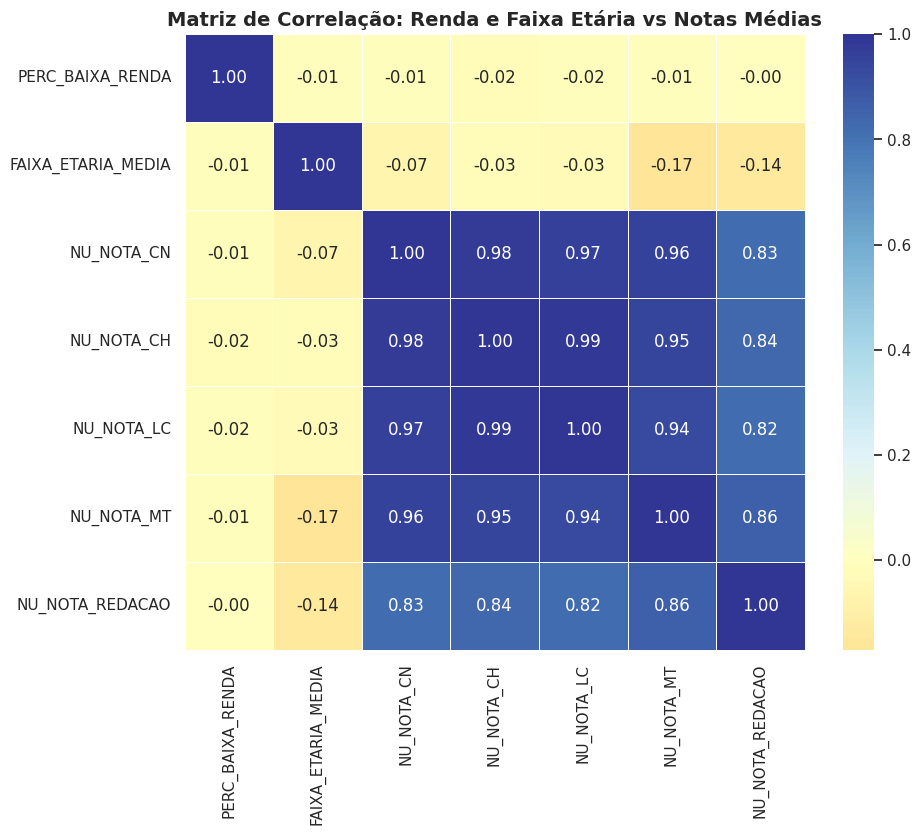

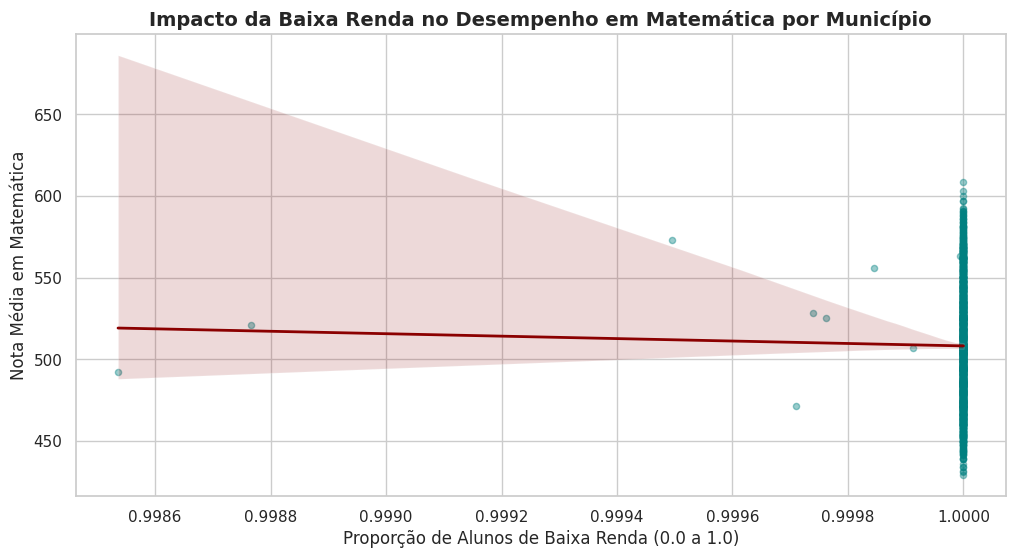

In [6]:
# 1. Matriz de Correlação
plt.figure(figsize=(10, 8))
# Selecionando as colunas numéricas de interesse
cols_corr = ['PERC_BAIXA_RENDA', 'FAIXA_ETARIA_MEDIA', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
matriz_corr = df_cidades[cols_corr].corr()

# Plotando o Heatmap
sns.heatmap(matriz_corr, annot=True, cmap='RdYlBu', center=0, fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação: Renda e Faixa Etária vs Notas Médias', fontsize=14, fontweight='bold')
plt.show()

print("\n" + "="*50 + "\n")

# 2. Scatter Plot (Gráfico de Dispersão com Linha de Tendência)
plt.figure(figsize=(12, 6))
# O regplot traça os pontos e já calcula uma linha de regressão linear
sns.regplot(data=df_cidades, x='PERC_BAIXA_RENDA', y='NU_NOTA_MT',
            scatter_kws={'alpha':0.4, 'color': 'teal', 's': 20},
            line_kws={'color': 'darkred', 'linewidth': 2})

plt.title('Impacto da Baixa Renda no Desempenho em Matemática por Município', fontsize=14, fontweight='bold')
plt.xlabel('Proporção de Alunos de Baixa Renda (0.0 a 1.0)', fontsize=12)
plt.ylabel('Nota Média em Matemática', fontsize=12)
plt.show()

### 4. Engenharia de Variáveis (Feature Engineering)
Para aprofundar a nossa análise e preparar o modelo de *Machine Learning* da Etapa 3, criámos novas métricas (*features*) a partir dos dados originais.
A principal métrica desenvolvida foi a **Taxa de Abstenção Municipal**. Em vez de apenas descartar os alunos faltosos, utilizámos a diferença entre o total de inscrições e o total de presenças efetivas nos dois dias de prova para calcular a percentagem de abstenção de cada município. O objetivo é investigar se a vulnerabilidade económica (baixa renda) também influencia a desistência dos candidatos.


In [7]:
# ==========================================

print("A calcular a Taxa de Abstenção por município...")

# 1. Total de inscritos por município (da base bruta de Participantes)
total_inscritos = df_part.groupby('CO_MUNICIPIO_PROVA').size().reset_index(name='TOTAL_INSCRITOS')

# 2. Total de presentes por município (da base de Resultados, usando as flags de presença)
# Consideramos "presente" quem compareceu aos dois dias principais
presentes = df_res[(df_res['TP_PRESENCA_CH'] == 1) & (df_res['TP_PRESENCA_MT'] == 1)]
total_presentes = presentes.groupby('CO_MUNICIPIO_PROVA').size().reset_index(name='TOTAL_PRESENTES')

# 3. Cruzar as duas contagens
df_abstencao = pd.merge(total_inscritos, total_presentes, on='CO_MUNICIPIO_PROVA', how='left')

# Preencher com 0 caso algum município extremo não tenha tido qualquer presente
df_abstencao['TOTAL_PRESENTES'] = df_abstencao['TOTAL_PRESENTES'].fillna(0)

# 4. A Mágica do Feature Engineering: Criar a variável derivada
df_abstencao['TAXA_ABSTENCAO'] = 1 - (df_abstencao['TOTAL_PRESENTES'] / df_abstencao['TOTAL_INSCRITOS'])

# 5. Adicionar esta nova variável ao nosso dataset final (Camada Gold)
df_cidades = pd.merge(df_cidades, df_abstencao[['CO_MUNICIPIO_PROVA', 'TAXA_ABSTENCAO']], on='CO_MUNICIPIO_PROVA', how='inner')

print("Feature 'TAXA_ABSTENCAO' criada e integrada com sucesso!")
display(df_cidades[['SG_UF_PROVA', 'TOTAL_CANDIDATOS', 'TAXA_ABSTENCAO', 'NU_NOTA_MT', 'PERC_BAIXA_RENDA']].head())

A calcular a Taxa de Abstenção por município...
Feature 'TAXA_ABSTENCAO' criada e integrada com sucesso!


,SG_UF_PROVA,TOTAL_CANDIDATOS,TAXA_ABSTENCAO,NU_NOTA_MT,PERC_BAIXA_RENDA
0,RO,471,0.318471,488.545483,1.0
1,RO,2505,0.374850,506.835504,1.0
2,RO,2497,0.309571,515.788747,1.0
3,RO,414,0.364734,479.340684,1.0
4,RO,431,0.280742,505.912258,1.0


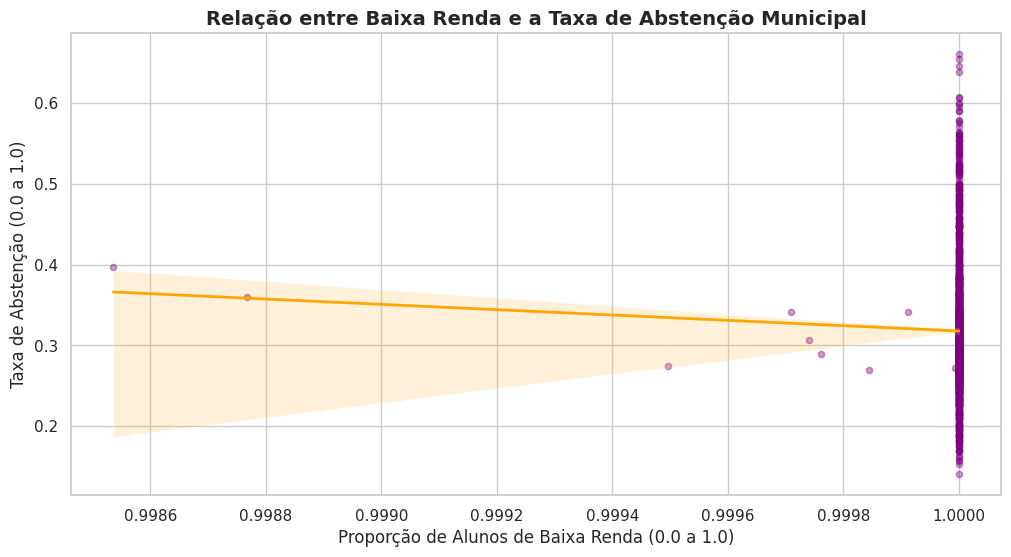

In [8]:
# Visualização do Feature Engineering

plt.figure(figsize=(12, 6))
# Plot da relação entre Baixa Renda e a nova variável de Abstenção
sns.regplot(data=df_cidades, x='PERC_BAIXA_RENDA', y='TAXA_ABSTENCAO',
            scatter_kws={'alpha':0.4, 'color': 'purple', 's': 20},
            line_kws={'color': 'orange', 'linewidth': 2})

plt.title('Relação entre Baixa Renda e a Taxa de Abstenção Municipal', fontsize=14, fontweight='bold')
plt.xlabel('Proporção de Alunos de Baixa Renda (0.0 a 1.0)', fontsize=12)
plt.ylabel('Taxa de Abstenção (0.0 a 1.0)', fontsize=12)
plt.show()

### 5. Camada Gold: Preparação para Machine Learning (Etapa 3)
Para garantir que o algoritmo de clusterização (K-Means) que será aplicado na Etapa 3 funcione corretamente, precisamos padronizar as variáveis numéricas. Como as notas variam de 0 a 1000 e as taxas (renda e abstenção) variam de 0 a 1, o algoritmo daria um peso desproporcional às notas. Utilizaremos o `StandardScaler` para transformar os dados em *Z-scores*, colocando todas as variáveis na mesma escala de importância.



In [9]:
# ==========================================
# Padronização (Scaling)
# ==========================================

print("Preparando a Camada Gold (Padronização de Variáveis)...")

# Selecionamos as variáveis numéricas vitais para o modelo
cols_para_padronizar = ['PERC_BAIXA_RENDA', 'TAXA_ABSTENCAO', 'FAIXA_ETARIA_MEDIA',
                        'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

# Inicializamos o padronizador
scaler = StandardScaler()

# Criamos o dataset final da Camada Gold
df_cidades_gold = df_cidades.copy()

# Aplicamos a transformação matemática
df_cidades_gold[cols_para_padronizar] = scaler.fit_transform(df_cidades_gold[cols_para_padronizar])

print("✅ Variáveis padronizadas com sucesso! O dataset está pronto para o modelo de Clusterização.")
display(df_cidades_gold[['SG_UF_PROVA', 'PERC_BAIXA_RENDA', 'TAXA_ABSTENCAO', 'NU_NOTA_MT']].head())

Preparando a Camada Gold (Padronização de Variáveis)...
✅ Variáveis padronizadas com sucesso! O dataset está pronto para o modelo de Clusterização.


,SG_UF_PROVA,PERC_BAIXA_RENDA,TAXA_ABSTENCAO,NU_NOTA_MT
0,RO,0.049701,0.006906,-0.574904
1,RO,0.049701,0.749535,-0.042627
2,RO,0.049701,-0.110324,0.217931
3,RO,0.049701,0.616286,-0.842783
4,RO,0.049701,-0.490063,-0.069495
